=== MATRIZ DE CARACTERÍSTICAS CONSOLIDADA (Primeras filas) ===
       Fecha  Produccion_lts_kg  Consumo_Gas_m3  Mes  Sopladoras_Activas  \
0 2023-01-01            1114850        43.38383    1                   0   
1 2023-02-01            2329571        74.46603    2                   0   
2 2023-03-01            1751127       101.79547    3                   0   
3 2023-04-01            2720075        80.06237    4                   0   
4 2023-05-01            1147140        68.74683    5                   0   

   kWh_Total  
0   264947.0  
1   517814.0  
2   428057.0  
3   420763.0  
4   406760.0  


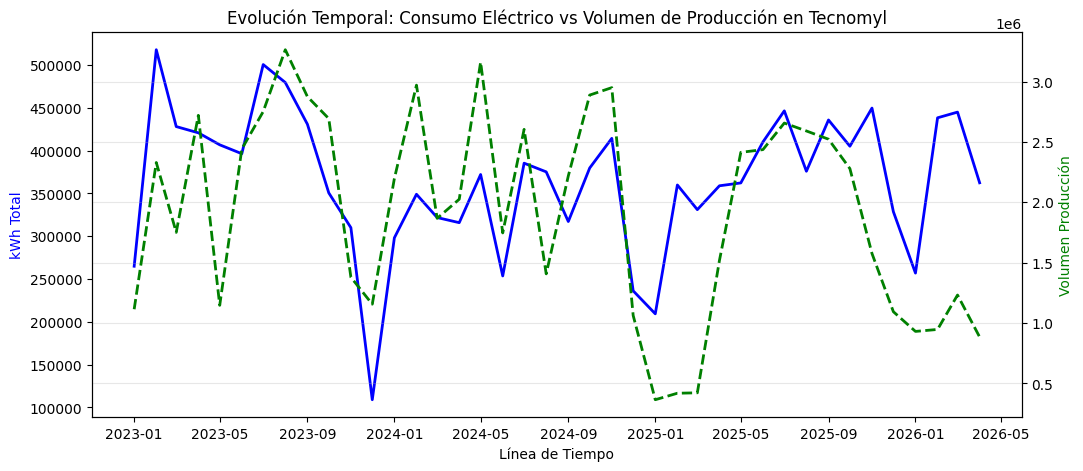

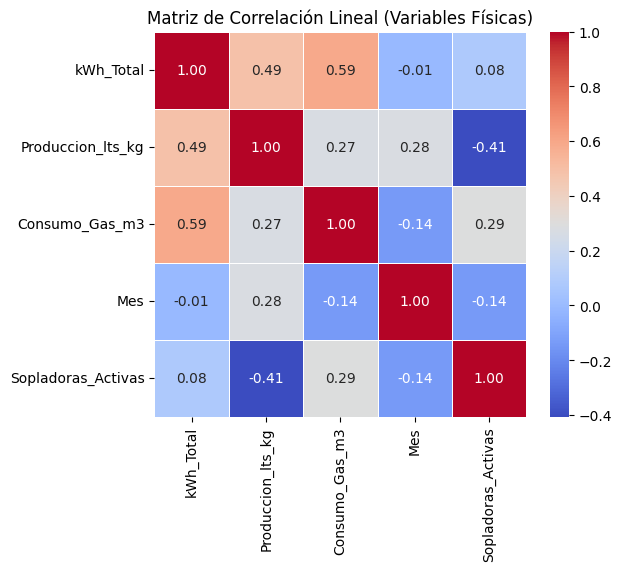

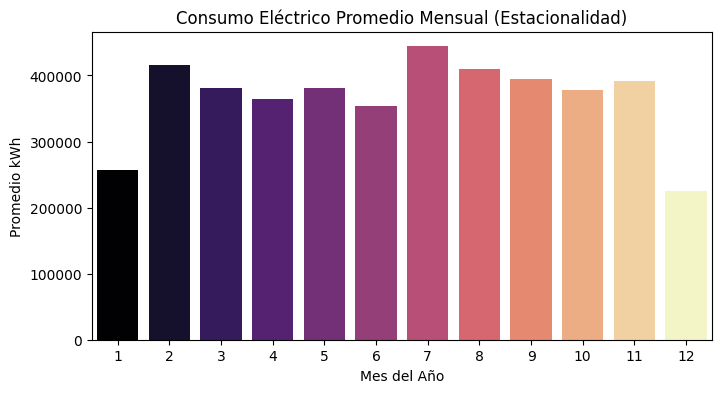


MÉTRICAS DE EVALUACIÓN DEL MODELO CON FILTRO ESTACIONAL
Mean Absolute Error (MAE):     39,871.74 kWh
Root Mean Squared Error (RMSE): 47,611.82 kWh
Coeficiente de Determinación (R²): 0.4582
Importancia de Feature [Produccion_lts_kg]: 63.91%
Importancia de Feature [Consumo_Gas_m3]: 29.16%
Importancia de Feature [Parada_Fin_Anio]: 6.93%


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================================================================
# 1. CARGA Y PREPARACIÓN DE DATOS (INGENIERÍA DE CARACTERÍSTICAS)
# =========================================================================

# Se levanta el archivo que ya contiene los datos reales de gas y el flag estructural
df = pd.read_csv('data/processed/features_energia_tecnomyl.csv')
df['Fecha'] = pd.to_datetime(df['Fecha'])

# A. Definición del Target (Variable Objetivo)
df['kWh_Total'] = df['kWh_Medidor_1'] + df['kWh_Medidor_2']

# B. Extracción de Factores de Tiempo
df['Mes'] = df['Fecha'].dt.month
df['Año'] = df['Fecha'].dt.year

print("=== MATRIZ DE CARACTERÍSTICAS CONSOLIDADA (Primeras filas) ===")
print(df[['Fecha', 'Produccion_lts_kg', 'Consumo_Gas_m3', 'Mes', 'Sopladoras_Activas', 'kWh_Total']].head())


# =========================================================================
# 2. ANÁLISIS EXPLORATORIO DE DATOS (EDA) - GENERACIÓN DE GRÁFICOS
# =========================================================================
os.makedirs('reports/figures', exist_ok=True)

# Gráfico 1: Evolución Temporal del Consumo vs Producción
plt.figure(figsize=(12, 5))
ax1 = plt.gca()
ax2 = ax1.twinx()
ax1.plot(df['Fecha'], df['kWh_Total'], color='blue', label='Consumo Eléctrico (kWh)', linewidth=2)
ax2.plot(df['Fecha'], df['Produccion_lts_kg'], color='green', linestyle='--', label='Producción (lts-kg)', linewidth=2)
ax1.set_xlabel('Línea de Tiempo')
ax1.set_ylabel('kWh Total', color='blue')
ax2.set_ylabel('Volumen Producción', color='green')
plt.title('Evolución Temporal: Consumo Eléctrico vs Volumen de Producción en Tecnomyl')
plt.grid(True, alpha=0.3)
plt.savefig('reports/figures/evolucion_temporal.png', bbox_inches='tight')
plt.show()

# Gráfico 2: Matriz de Correlación (Heatmap) con variable estructural incluida
plt.figure(figsize=(6, 5))
variables_core = ['kWh_Total', 'Produccion_lts_kg', 'Consumo_Gas_m3', 'Mes', 'Sopladoras_Activas']
sns.heatmap(df[variables_core].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación Lineal (Variables Físicas)')
plt.savefig('reports/figures/matriz_correlacion.png', bbox_inches='tight')
plt.show()

# Gráfico 3: Estacionalidad del Consumo por Mes
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='Mes', y='kWh_Total', hue='Mes', palette='magma', errorbar=None, legend=False)
plt.title('Consumo Eléctrico Promedio Mensual (Estacionalidad)')
plt.xlabel('Mes del Año')
plt.ylabel('Promedio kWh')
plt.savefig('reports/figures/estacionalidad_mensual.png', bbox_inches='tight')
plt.show()


# =========================================================================
# 3. DIVISION DE DATOS Y ENTRENAMIENTO DEL MODELO (CON ESTACIONALIDAD)
# =========================================================================

# Creamos una variable binaria para capturar el freno de diciembre (12) y enero (1)
df['Parada_Fin_Anio'] = np.where(df['Mes'].isin([1, 12]), 1, 0)

# Definimos las variables predictoras finales
features = ['Produccion_lts_kg', 'Consumo_Gas_m3', 'Parada_Fin_Anio']
X = df[features]
y_medidor1 = df['kWh_Medidor_1']

# División cronológica estricta (80% Train, 20% Test)
X_train, X_test, y_train_m1, y_test_m1 = train_test_split(X, y_medidor1, test_size=0.2, shuffle=False)

# Recuperación de datos reales del Medidor 2 y Totales para test
y_test_m2 = df.loc[X_test.index, 'kWh_Medidor_2']
y_test_total_real = df.loc[X_test.index, 'kWh_Total']

# Inicialización del modelo con hiperparámetros estables
modelo_rf = RandomForestRegressor(
    n_estimators=30,
    max_depth=3,
    min_samples_split=3,
    random_state=42
)
modelo_rf.fit(X_train, y_train_m1)

# Predicción del Medidor 1
y_pred_m1 = modelo_rf.predict(X_test)

# RECONSTRUCCIÓN: Sumatoria del comportamiento base del Medidor 2
y_pred_total = y_pred_m1 + y_test_m2


# =========================================================================
# 4. CÁLCULO DE MÉTRICAS DE EVALUACIÓN SOBRE EL CONSUMO TOTAL
# =========================================================================

mae = mean_absolute_error(y_test_total_real, y_pred_total)
rmse = np.sqrt(mean_squared_error(y_test_total_real, y_pred_total))
r2 = r2_score(y_test_total_real, y_pred_total)

print("\n" + "="*50)
print("MÉTRICAS DE EVALUACIÓN DEL MODELO CON FILTRO ESTACIONAL")
print("="*50)
print(f"Mean Absolute Error (MAE):     {mae:,.2f} kWh")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f} kWh")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")
print("="*50)

# Importancia de las variables físicas y la bandera estacional
importancias = modelo_rf.feature_importances_
for feat, imp in zip(features, importancias):
    print(f"Importancia de Feature [{feat}]: {imp*100:.2f}%")

